In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_excel("dataset_set_A_aguas_residuales.xlsx")

print("Primeras filas del dataset:")
display(df.head())

print("\nDimensiones del dataset:")
print(df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())

print("\nInformación general:")
df.info()


Primeras filas del dataset:


,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
0,2025-08-17,Planta Sur,6562,271,324,7.12,1261.1,440.3,40.0,0
1,2025-09-07,Planta Sur,5336,322,230,7.01,1629.3,561.2,26.8,1
2,2025-07-26,Planta Norte,5755,318,282,6.79,1469.2,441.6,45.2,0
3,2025-10-27,Planta Centro,6840,216,167,7.01,1764.8,560.0,38.0,0
4,2025-09-06,Planta Centro,6803,326,200,7.55,1409.3,654.0,32.1,0



Dimensiones del dataset:
(200, 10)

Columnas disponibles:
['fecha_registro', 'planta', 'caudal_entrada_m3_d', 'DBO_entrada_mg_L', 'SST_entrada_mg_L', 'pH_entrada', 'energia_aeracion_kWh', 'lodos_generados_kg_d', 'DBO_salida_mg_L', 'cumplimiento_norma']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha_registro        200 non-null    object 
 1   planta                200 non-null    object 
 2   caudal_entrada_m3_d   200 non-null    int64  
 3   DBO_entrada_mg_L      200 non-null    int64  
 4   SST_entrada_mg_L      200 non-null    int64  
 5   pH_entrada            200 non-null    float64
 6   energia_aeracion_kWh  200 non-null    float64
 7   lodos_generados_kg_d  200 non-null    float64
 8   DBO_salida_mg_L       200 non-null    float64
 9   cumplimiento_norma    200 non-null    int64  
dtypes:

In [2]:
# Estadísticas descriptivas de las variables principales
variables_principales = [
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "SST_entrada_mg_L",
    "pH_entrada",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d",
    "DBO_salida_mg_L",
    "cumplimiento_norma"
]

estadisticas = df[variables_principales].describe().round(2)

print("Estadísticas descriptivas de AquaLimpia S. A.:")
display(estadisticas)

print("\nCantidad de valores nulos por variable:")
print(df.isnull().sum())

print("\nDistribución del cumplimiento normativo:")
print(df["cumplimiento_norma"].value_counts())

Estadísticas descriptivas de AquaLimpia S. A.:


,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,5059.28,280.14,232.67,7.16,1256.39,428.80,36.18,0.22
std,1410.97,75.57,64.29,0.42,420.15,144.74,13.26,0.42
min,1500.00,90.00,70.00,6.18,279.70,113.70,10.20,0.00
25%,4193.75,223.00,192.50,6.85,950.65,321.17,26.08,0.00
50%,5092.50,284.00,233.50,7.14,1212.85,429.70,35.15,0.00
75%,6037.75,333.25,277.50,7.45,1516.75,524.83,45.82,0.00
max,9205.00,481.00,391.00,8.27,2434.00,971.70,79.00,1.00



Cantidad de valores nulos por variable:
fecha_registro          0
planta                  0
caudal_entrada_m3_d     0
DBO_entrada_mg_L        0
SST_entrada_mg_L        0
pH_entrada              0
energia_aeracion_kWh    0
lodos_generados_kg_d    0
DBO_salida_mg_L         0
cumplimiento_norma      0
dtype: int64

Distribución del cumplimiento normativo:
cumplimiento_norma
0    155
1     45
Name: count, dtype: int64


In [3]:
# Preparación de variables para el análisis

# Convertir fecha a formato datetime
df["fecha_registro"] = pd.to_datetime(df["fecha_registro"])

# Calcular eficiencia de remoción de DBO (%)
df["eficiencia_DBO_pct"] = (
    (df["DBO_entrada_mg_L"] - df["DBO_salida_mg_L"])
    / df["DBO_entrada_mg_L"]
) * 100

# Resumen por planta
resumen_planta = df.groupby("planta").agg(
    registros=("planta", "size"),
    caudal_promedio=("caudal_entrada_m3_d", "mean"),
    DBO_entrada_promedio=("DBO_entrada_mg_L", "mean"),
    DBO_salida_promedio=("DBO_salida_mg_L", "mean"),
    eficiencia_DBO_promedio=("eficiencia_DBO_pct", "mean"),
    energia_promedio=("energia_aeracion_kWh", "mean"),
    cumplimiento_promedio=("cumplimiento_norma", "mean")
).round(2)

# Convertir cumplimiento a porcentaje
resumen_planta["cumplimiento_pct"] = (
    resumen_planta["cumplimiento_promedio"] * 100
).round(2)

print("Resumen del desempeño por planta:")
display(resumen_planta)

Resumen del desempeño por planta:


,registros,caudal_promedio,DBO_entrada_promedio,DBO_salida_promedio,eficiencia_DBO_promedio,energia_promedio,cumplimiento_promedio,cumplimiento_pct
planta,,,,,,,,
Planta Centro,75,5112.72,285.19,35.90,87.51,1260.85,0.23,23.0
Planta Norte,71,5287.87,275.85,36.56,86.65,1299.31,0.17,17.0
Planta Sur,54,4684.52,278.80,36.06,87.10,1193.78,0.30,30.0


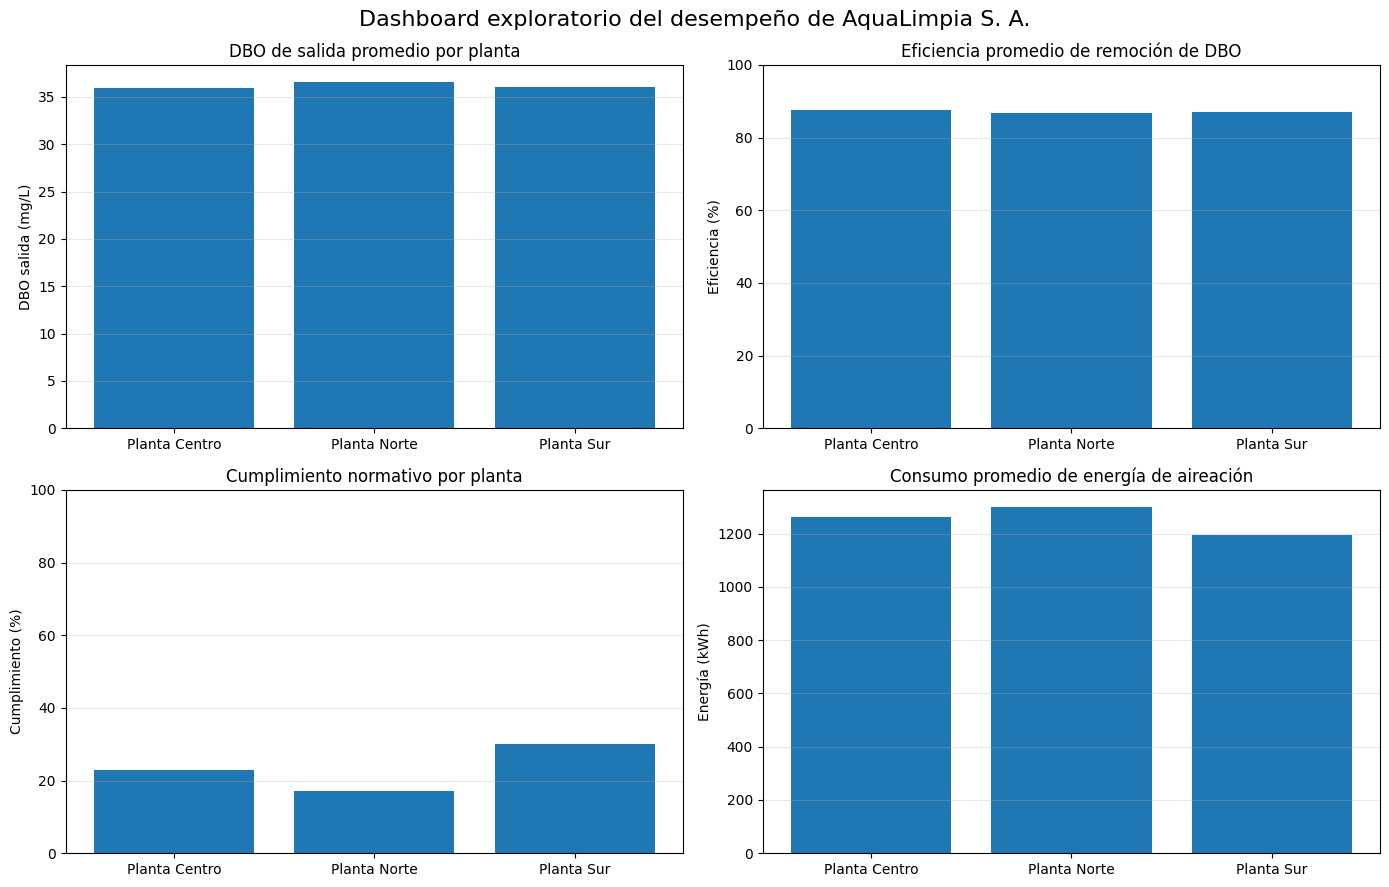

In [10]:
import matplotlib.pyplot as plt

# Preparar indicadores por planta
dashboard = resumen_planta.copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. DBO de salida promedio
axes[0, 0].bar(
    dashboard.index,
    dashboard["DBO_salida_promedio"]
)
axes[0, 0].set_title("DBO de salida promedio por planta")
axes[0, 0].set_ylabel("DBO salida (mg/L)")
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Eficiencia de remoción de DBO
axes[0, 1].bar(
    dashboard.index,
    dashboard["eficiencia_DBO_promedio"]
)
axes[0, 1].set_title("Eficiencia promedio de remoción de DBO")
axes[0, 1].set_ylabel("Eficiencia (%)")
axes[0, 1].set_ylim(0, 100)
axes[0, 1].grid(axis="y", alpha=0.3)

# 3. Cumplimiento normativo
axes[1, 0].bar(
    dashboard.index,
    dashboard["cumplimiento_pct"]
)
axes[1, 0].set_title("Cumplimiento normativo por planta")
axes[1, 0].set_ylabel("Cumplimiento (%)")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].grid(axis="y", alpha=0.3)

# 4. Energía de aireación promedio
axes[1, 1].bar(
    dashboard.index,
    dashboard["energia_promedio"]
)
axes[1, 1].set_title("Consumo promedio de energía de aireación")
axes[1, 1].set_ylabel("Energía (kWh)")
axes[1, 1].grid(axis="y", alpha=0.3)

fig.suptitle(
    "Dashboard exploratorio del desempeño de AquaLimpia S. A.",
    fontsize=16
)

plt.tight_layout()
plt.savefig(
    "dashboard_aqualimpia.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [5]:
%%writefile analisis_aqualimpia.py

import pandas as pd
import matplotlib.pyplot as plt

# Cargar dataset
df = pd.read_excel("dataset_set_A_aguas_residuales.xlsx")

# Preparar variables
df["fecha_registro"] = pd.to_datetime(df["fecha_registro"])

df["eficiencia_DBO_pct"] = (
    (df["DBO_entrada_mg_L"] - df["DBO_salida_mg_L"])
    / df["DBO_entrada_mg_L"]
) * 100

# Resumen por planta
resumen_planta = df.groupby("planta").agg(
    registros=("planta", "size"),
    caudal_promedio=("caudal_entrada_m3_d", "mean"),
    DBO_entrada_promedio=("DBO_entrada_mg_L", "mean"),
    DBO_salida_promedio=("DBO_salida_mg_L", "mean"),
    eficiencia_DBO_promedio=("eficiencia_DBO_pct", "mean"),
    energia_promedio=("energia_aeracion_kWh", "mean"),
    cumplimiento_promedio=("cumplimiento_norma", "mean")
).round(2)

resumen_planta["cumplimiento_pct"] = (
    resumen_planta["cumplimiento_promedio"] * 100
).round(2)

print("Resumen del desempeño por planta:")
print(resumen_planta)

# Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(
    resumen_planta.index,
    resumen_planta["DBO_salida_promedio"]
)
axes[0, 0].set_title("DBO de salida promedio por planta")
axes[0, 0].set_ylabel("DBO salida (mg/L)")
axes[0, 0].grid(axis="y", alpha=0.3)

axes[0, 1].bar(
    resumen_planta.index,
    resumen_planta["eficiencia_DBO_promedio"]
)
axes[0, 1].set_title("Eficiencia promedio de remoción de DBO")
axes[0, 1].set_ylabel("Eficiencia (%)")
axes[0, 1].set_ylim(0, 100)
axes[0, 1].grid(axis="y", alpha=0.3)

axes[1, 0].bar(
    resumen_planta.index,
    resumen_planta["cumplimiento_pct"]
)
axes[1, 0].set_title("Cumplimiento normativo por planta")
axes[1, 0].set_ylabel("Cumplimiento (%)")
axes[1, 0].set_ylim(0, 100)
axes[1, 0].grid(axis="y", alpha=0.3)

axes[1, 1].bar(
    resumen_planta.index,
    resumen_planta["energia_promedio"]
)
axes[1, 1].set_title("Consumo promedio de energía de aireación")
axes[1, 1].set_ylabel("Energía (kWh)")
axes[1, 1].grid(axis="y", alpha=0.3)

fig.suptitle(
    "Dashboard exploratorio del desempeño de AquaLimpia S. A.",
    fontsize=16
)

plt.tight_layout()
plt.show()

Writing analisis_aqualimpia.py


In [6]:
# PREGUNTA 2
# Flujo de trabajo reproducible para el análisis de AquaLimpia S. A.

import pandas as pd

# 1. Carga de datos
df_flujo = pd.read_excel("dataset_set_A_aguas_residuales.xlsx")

# 2. Validación inicial
print("=== 1. VALIDACIÓN DEL DATASET ===")
print("Filas:", df_flujo.shape[0])
print("Columnas:", df_flujo.shape[1])
print("Valores nulos:", df_flujo.isnull().sum().sum())
print("Duplicados:", df_flujo.duplicated().sum())

# 3. Preparación de los datos
df_flujo["fecha_registro"] = pd.to_datetime(df_flujo["fecha_registro"])

df_flujo["eficiencia_DBO_pct"] = (
    (df_flujo["DBO_entrada_mg_L"] - df_flujo["DBO_salida_mg_L"])
    / df_flujo["DBO_entrada_mg_L"]
) * 100

print("\n=== 2. PREPARACIÓN ===")
print("Variable fecha convertida correctamente.")
print("Variable eficiencia_DBO_pct creada.")

# 4. Análisis por planta
resultado_flujo = df_flujo.groupby("planta").agg(
    registros=("planta", "size"),
    DBO_salida_promedio=("DBO_salida_mg_L", "mean"),
    eficiencia_DBO_promedio=("eficiencia_DBO_pct", "mean"),
    energia_promedio=("energia_aeracion_kWh", "mean"),
    cumplimiento_promedio=("cumplimiento_norma", "mean")
).round(2)

resultado_flujo["cumplimiento_pct"] = (
    resultado_flujo["cumplimiento_promedio"] * 100
).round(2)

print("\n=== 3. RESULTADOS POR PLANTA ===")
display(resultado_flujo)

print("\n=== 4. FLUJO COMPLETADO ===")
print("Carga -> Validación -> Preparación -> Análisis -> Resultados")

=== 1. VALIDACIÓN DEL DATASET ===
Filas: 200
Columnas: 10
Valores nulos: 0
Duplicados: 0

=== 2. PREPARACIÓN ===
Variable fecha convertida correctamente.
Variable eficiencia_DBO_pct creada.

=== 3. RESULTADOS POR PLANTA ===


,registros,DBO_salida_promedio,eficiencia_DBO_promedio,energia_promedio,cumplimiento_promedio,cumplimiento_pct
planta,,,,,,
Planta Centro,75,35.90,87.51,1260.85,0.23,23.0
Planta Norte,71,36.56,86.65,1299.31,0.17,17.0
Planta Sur,54,36.06,87.10,1193.78,0.30,30.0



=== 4. FLUJO COMPLETADO ===
Carga -> Validación -> Preparación -> Análisis -> Resultados


# Documentación técnica del análisis de AquaLimpia S. A.

## 1. Objetivo del análisis

El objetivo del proyecto es analizar el desempeño de las plantas de tratamiento de aguas residuales de AquaLimpia S. A. mediante técnicas de ciencia de datos. Para ello, se utilizan indicadores relacionados con el tratamiento del agua, la eficiencia de remoción de DBO, el consumo de energía y el cumplimiento normativo.

El análisis considera las plantas Centro, Norte y Sur, permitiendo comparar su comportamiento e identificar diferencias en su desempeño operacional.

## 2. Fuente de datos

El análisis utiliza el archivo `dataset_set_A_aguas_residuales.xlsx`, compuesto por 200 registros y 10 variables.

Entre las principales variables se encuentran:

- Fecha de registro.
- Planta de tratamiento.
- Caudal de entrada.
- DBO de entrada.
- SST de entrada.
- pH de entrada.
- Energía de aireación.
- Lodos generados.
- DBO de salida.
- Cumplimiento normativo.

Durante la validación inicial se comprobó que el conjunto de datos no presenta valores nulos ni registros duplicados.

## 3. Proceso de análisis

El flujo de trabajo se organizó en las siguientes etapas:

**Carga → Validación → Preparación → Análisis → Resultados**

### Carga
Se cargó el dataset desde un archivo Excel utilizando la biblioteca Pandas.

### Validación
Se revisaron las dimensiones del dataset, los tipos de datos, los valores nulos y los registros duplicados.

### Preparación
La variable `fecha_registro` se convirtió a formato de fecha. Además, se creó la variable `eficiencia_DBO_pct` para representar porcentualmente la eficiencia de remoción de DBO.

### Análisis
Los registros fueron agrupados según la planta de tratamiento y se calcularon indicadores de desempeño, entre ellos:

- DBO de salida promedio.
- Eficiencia promedio de remoción de DBO.
- Consumo promedio de energía.
- Porcentaje de cumplimiento normativo.

### Presentación de resultados
Los resultados fueron organizados mediante tablas y visualizaciones para facilitar la comparación entre las plantas.

## 4. Principales resultados

Las tres plantas presentan una eficiencia promedio de remoción de DBO cercana al 87 %. Sin embargo, se observan diferencias en el cumplimiento normativo.

- Planta Centro: 23 % de cumplimiento.
- Planta Norte: 17 % de cumplimiento.
- Planta Sur: 30 % de cumplimiento.

En cuanto al consumo promedio de energía de aireación, la Planta Norte presenta aproximadamente 1299,31 kWh, seguida de Planta Centro con 1260,85 kWh y Planta Sur con 1193,78 kWh.

Los resultados permiten observar que una eficiencia de remoción de DBO relativamente similar entre las plantas no necesariamente se traduce en el mismo nivel de cumplimiento normativo. Por este motivo, es importante analizar conjuntamente los diferentes indicadores operacionales.

## 5. Conclusión

La documentación técnica permite comprender cómo se desarrolló el análisis, qué datos fueron utilizados, qué transformaciones se realizaron y cómo se obtuvieron los resultados. Además, facilita la reproducción del procedimiento por parte de otros usuarios y permite mantener trazabilidad sobre las decisiones tomadas durante el proyecto.

En AquaLimpia S. A., documentar el proceso permite relacionar los resultados obtenidos con las etapas que los generaron y facilita futuras actualizaciones del análisis cuando se incorporen nuevos registros.

In [7]:
%%writefile funciones_aqualimpia.py

import pandas as pd
import numpy as np

def calcular_eficiencia_dbo(dbo_entrada, dbo_salida):
    """
    Calcula el porcentaje de eficiencia de remoción de DBO.
    """
    return ((dbo_entrada - dbo_salida) / dbo_entrada) * 100


def resumen_por_planta(df):
    """
    Genera un resumen de los principales indicadores por planta.
    """
    datos = df.copy()

    datos["eficiencia_DBO_pct"] = calcular_eficiencia_dbo(
        datos["DBO_entrada_mg_L"],
        datos["DBO_salida_mg_L"]
    )

    resumen = datos.groupby("planta").agg(
        registros=("planta", "size"),
        DBO_salida_promedio=("DBO_salida_mg_L", "mean"),
        eficiencia_DBO_promedio=("eficiencia_DBO_pct", "mean"),
        energia_promedio=("energia_aeracion_kWh", "mean"),
        cumplimiento_promedio=("cumplimiento_norma", "mean")
    ).round(2)

    resumen["cumplimiento_pct"] = (
        resumen["cumplimiento_promedio"] * 100
    ).round(2)

    return resumen


def obtener_indicadores_generales(df):
    """
    Obtiene indicadores generales utilizando NumPy.
    """
    return {
        "registros": len(df),
        "DBO_salida_media": round(np.mean(df["DBO_salida_mg_L"]), 2),
        "energia_media": round(np.mean(df["energia_aeracion_kWh"]), 2)
    }

Writing funciones_aqualimpia.py


In [8]:
from funciones_aqualimpia import (
    calcular_eficiencia_dbo,
    resumen_por_planta,
    obtener_indicadores_generales
)

# Utilizar las funciones externas
resumen_modular = resumen_por_planta(df)
indicadores_generales = obtener_indicadores_generales(df)

print("=== RESUMEN GENERADO DESDE EL MÓDULO EXTERNO ===")
display(resumen_modular)

print("\n=== INDICADORES GENERALES ===")
for indicador, valor in indicadores_generales.items():
    print(f"{indicador}: {valor}")

print("\nMódulo externo utilizado correctamente.")

=== RESUMEN GENERADO DESDE EL MÓDULO EXTERNO ===


,registros,DBO_salida_promedio,eficiencia_DBO_promedio,energia_promedio,cumplimiento_promedio,cumplimiento_pct
planta,,,,,,
Planta Centro,75,35.90,87.51,1260.85,0.23,23.0
Planta Norte,71,36.56,86.65,1299.31,0.17,17.0
Planta Sur,54,36.06,87.10,1193.78,0.30,30.0



=== INDICADORES GENERALES ===
registros: 200
DBO_salida_media: 36.18
energia_media: 1256.39

Módulo externo utilizado correctamente.


In [9]:
# PREGUNTA 5 - Análisis de calidad de los datos

import pandas as pd
import numpy as np

print("=== ANÁLISIS DE CALIDAD DE LOS DATOS ===")

# 1. Completitud
print("\n1. VALORES NULOS")
print(df.isnull().sum())
print("Total de valores nulos:", df.isnull().sum().sum())

# 2. Duplicados
print("\n2. REGISTROS DUPLICADOS")
print("Cantidad de duplicados:", df.duplicated().sum())

# 3. Estadísticas para detectar valores extremos
variables_numericas = [
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "SST_entrada_mg_L",
    "pH_entrada",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d",
    "DBO_salida_mg_L"
]

print("\n3. RANGOS DE VARIABLES NUMÉRICAS")
rangos = df[variables_numericas].agg(["min", "max", "mean"]).round(2)
display(rangos)

# 4. Consistencia de variables categóricas
print("\n4. PLANTAS REGISTRADAS")
print(df["planta"].value_counts())

print("\n5. CUMPLIMIENTO NORMATIVO")
print(df["cumplimiento_norma"].value_counts())

# 5. Detección de valores atípicos mediante IQR
print("\n6. POSIBLES VALORES ATÍPICOS (MÉTODO IQR)")

for columna in variables_numericas:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print(f"{columna}: {len(atipicos)} posibles valores atípicos")

=== ANÁLISIS DE CALIDAD DE LOS DATOS ===

1. VALORES NULOS
fecha_registro          0
planta                  0
caudal_entrada_m3_d     0
DBO_entrada_mg_L        0
SST_entrada_mg_L        0
pH_entrada              0
energia_aeracion_kWh    0
lodos_generados_kg_d    0
DBO_salida_mg_L         0
cumplimiento_norma      0
eficiencia_DBO_pct      0
dtype: int64
Total de valores nulos: 0

2. REGISTROS DUPLICADOS
Cantidad de duplicados: 0

3. RANGOS DE VARIABLES NUMÉRICAS


,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L
min,1500.00,90.00,70.00,6.18,279.70,113.7,10.20
max,9205.00,481.00,391.00,8.27,2434.00,971.7,79.00
mean,5059.28,280.14,232.67,7.16,1256.39,428.8,36.18



4. PLANTAS REGISTRADAS
planta
Planta Centro    75
Planta Norte     71
Planta Sur       54
Name: count, dtype: int64

5. CUMPLIMIENTO NORMATIVO
cumplimiento_norma
0    155
1     45
Name: count, dtype: int64

6. POSIBLES VALORES ATÍPICOS (MÉTODO IQR)
caudal_entrada_m3_d: 2 posibles valores atípicos
DBO_entrada_mg_L: 0 posibles valores atípicos
SST_entrada_mg_L: 0 posibles valores atípicos
pH_entrada: 0 posibles valores atípicos
energia_aeracion_kWh: 3 posibles valores atípicos
lodos_generados_kg_d: 2 posibles valores atípicos
DBO_salida_mg_L: 2 posibles valores atípicos
